In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/trade_data.csv")
df.head()

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS_Code,CTS_Name,CTS_Full_Descriptor,...,F2014,F2015,F2016,F2017,F2018,F2019,F2020,F2021,F2022,F2023
0,1,"Afghanistan, Islamic Rep. of",AF,AFG,Comparative advantage in low carbon technology...,Index,Department of Economic and Social Affairs/Unit...,ECBTLA,Trade in Low Carbon Technology Products; Compa...,"Environment, Climate Change, Mitigation, Trade...",...,NaN,NaN,NaN,8.920000e-05,8.180000e-05,5.877250e-04,NaN,NaN,NaN,NaN
1,2,"Afghanistan, Islamic Rep. of",AF,AFG,Exports of low carbon technology products,US Dollars,Department of Economic and Social Affairs/Unit...,ECBTLX,Trade in Low Carbon Technology Products; Exports,"Environment, Climate Change, Mitigation, Trade...",...,NaN,NaN,NaN,3.401980e+03,3.217850e+03,2.408955e+04,NaN,NaN,NaN,NaN
2,3,"Afghanistan, Islamic Rep. of",AF,AFG,Exports of low carbon technology products as p...,Percent,Department of Economic and Social Affairs/Unit...,ECBTLX,Trade in Low Carbon Technology Products; Exports,"Environment, Climate Change, Mitigation, Trade...",...,NaN,NaN,NaN,1.800000e-05,1.750000e-05,1.276220e-04,NaN,NaN,NaN,NaN
3,4,"Afghanistan, Islamic Rep. of",AF,AFG,Exports of low carbon technology products as s...,Percent,Department of Economic and Social Affairs/Unit...,ECBTLX,Trade in Low Carbon Technology Products; Exports,"Environment, Climate Change, Mitigation, Trade...",...,NaN,NaN,NaN,4.077410e-04,3.676780e-04,2.788680e-03,NaN,NaN,NaN,NaN
4,5,"Afghanistan, Islamic Rep. of",AF,AFG,Imports of low carbon technology products,US Dollars,Department of Economic and Social Affairs/Unit...,ECBTLM,Trade in Low Carbon Technology Products; Imports,"Environment, Climate Change, Mitigation, Trade...",...,NaN,8503327.0,6561112.0,1.611734e+07,1.912370e+07,1.054682e+08,NaN,NaN,NaN,NaN


In [3]:
df.columns

Index(['ObjectId', 'Country', 'ISO2', 'ISO3', 'Indicator', 'Unit', 'Source',
       'CTS_Code', 'CTS_Name', 'CTS_Full_Descriptor', 'Trade_Flow', 'Scale',
       'F1994', 'F1995', 'F1996', 'F1997', 'F1998', 'F1999', 'F2000', 'F2001',
       'F2002', 'F2003', 'F2004', 'F2005', 'F2006', 'F2007', 'F2008', 'F2009',
       'F2010', 'F2011', 'F2012', 'F2013', 'F2014', 'F2015', 'F2016', 'F2017',
       'F2018', 'F2019', 'F2020', 'F2021', 'F2022', 'F2023'],
      dtype='object')

In [4]:
df["Trade_Flow"].value_counts()

Trade_Flow
Not Applicable    968
Imports           590
Exports           585
Name: count, dtype: int64

In [5]:
df.groupby("Trade_Flow").sum(numeric_only = True)

,ObjectId,F1994,F1995,F1996,F1997,F1998,F1999,F2000,F2001,F2002,...,F2014,F2015,F2016,F2017,F2018,F2019,F2020,F2021,F2022,F2023
Trade_Flow,,,,,,,,,,,,,,,,,,,,,
Exports,625766,2.515645e+11,3.204288e+11,3.463119e+11,3.621182e+11,3.736801e+11,3.981031e+11,4.656965e+11,4.520245e+11,4.636351e+11,...,1.527523e+12,1.430423e+12,1.392013e+12,1.614580e+12,1.742057e+12,1.788873e+12,1.833917e+12,2.281904e+12,2.180678e+12,2.260179e+12
Imports,632898,2.439931e+11,3.081365e+11,3.444114e+11,3.743121e+11,3.824558e+11,4.058027e+11,4.755391e+11,4.655900e+11,4.755448e+11,...,1.455910e+12,1.390020e+12,1.391842e+12,1.572232e+12,1.671858e+12,1.730227e+12,1.765454e+12,2.202975e+12,2.102845e+12,2.159801e+12
Not Applicable,1039796,5.026790e+11,6.421500e+11,6.935216e+11,7.240403e+11,7.465842e+11,7.965065e+11,9.305504e+11,9.044833e+11,9.263602e+11,...,3.054135e+12,2.862489e+12,2.781836e+12,3.225626e+12,3.488105e+12,3.576380e+12,3.666771e+12,4.560791e+12,4.360925e+12,4.520109e+12


In [6]:
result = df.groupby("Trade_Flow").sum(numeric_only = True).sum(axis = 1)

In [7]:
result_billion = result/ 1e9

for i in result_billion.index:
    print(i,":",
round(result_billion[i], 2),
          "Billion USD")

Exports : 33671.46 Billion USD
Imports : 32877.84 Billion USD
Not Applicable : 67328.96 Billion USD


In [8]:
import matplotlib.pyplot as plt

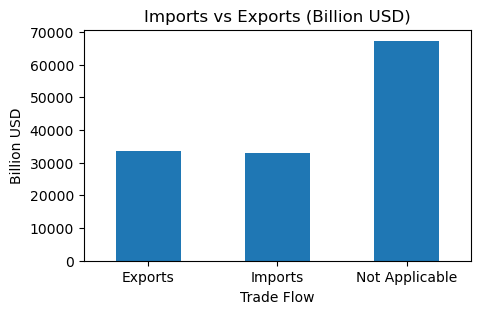

In [9]:
plt.figure(figsize = (5,3))
result_billion = result / 1e9
result_billion.plot(kind = "bar")
plt.title("Imports vs Exports (Billion USD)")
plt.ylabel("Billion USD")
plt.xlabel("Trade Flow")
plt.xticks(rotation = 0) 
plt.show()

In [10]:
country_trade = df.groupby("Country").sum(numeric_only=True).sum(axis=1)
country_trade.head()
for i in country_trade.index:
    print(i,":",
          round(country_trade[i],2),
          "Billion USD")

Afghanistan, Islamic Rep. of : 203928330.12 Billion USD
Albania : 2785654448.37 Billion USD
Algeria : 43549524739.63 Billion USD
Andorra, Principality of : 731177009.35 Billion USD
Angola : 16576829027.05 Billion USD
Anguilla : 15020289.42 Billion USD
Argentina : 96710515881.06 Billion USD
Armenia, Rep. of : 3442780750.46 Billion USD
Aruba, Kingdom of the Netherlands : 539317941.18 Billion USD
Australia : 357686209182.36 Billion USD
Austria : 733378443675.39 Billion USD
Azerbaijan, Rep. of : 12103414661.98 Billion USD
Bahamas, The : 2377193088.76 Billion USD
Bahrain, Kingdom of : 14148257844.27 Billion USD
Bangladesh : 9246497417.14 Billion USD
Barbados : 1578115564.95 Billion USD
Belarus, Rep. of : 47428647527.04 Billion USD
Belgium : 901047950056.88 Billion USD
Belgium-Luxembourg : 55985376663.0 Billion USD
Belize : 452676224.37 Billion USD
Benin : 1196936365.07 Billion USD
Bermuda : 409949962.99 Billion USD
Bhutan : 234025167.34 Billion USD
Bolivia : 11083408113.18 Billion USD
Bosni

In [11]:
top5 = country_trade.sort_values(ascending = False).head(5)

for i in top5.index:
    print(i,":",
round(top5[i]/1e9, 2),
          "Billion USD")
    

World : 66925.83 Billion USD
China, P.R.: Mainland : 9544.89 Billion USD
Germany : 8287.64 Billion USD
United States : 7669.67 Billion USD
Japan : 5190.7 Billion USD


In [12]:
df_top5 = df[df["Country"].isin(top5.index)] 

In [13]:
cp = df_top5.groupby(["Country","CTS_Name"]).sum(numeric_only = True).sum(axis =1)

In [14]:
top_products_country = cp.groupby(level = 0).idxmax()
top_products_country

Country
China, P.R.: Mainland    (China, P.R.: Mainland, Trade in Low Carbon Te...
Germany                  (Germany, Trade in Low Carbon Technology Produ...
Japan                     (Japan, Trade in Low Carbon Technology Products)
United States            (United States, Trade in Low Carbon Technology...
World                     (World, Trade in Low Carbon Technology Products)
dtype: object

In [15]:
df_top5 = df_top5[df_top5["Country"] != "World"]

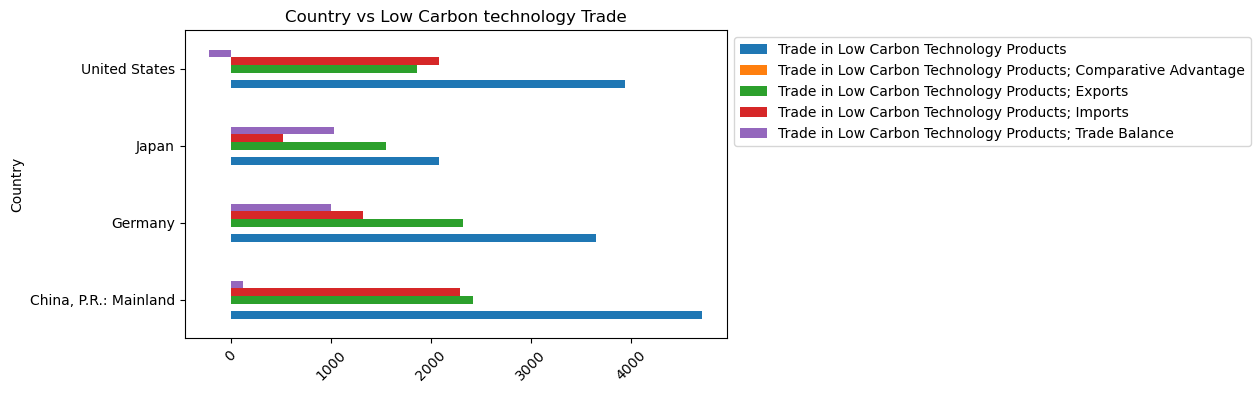

In [17]:
ct_chart = df_top5.groupby(["Country","CTS_Name"]).sum(numeric_only = True).sum(axis =1)/1e9
ct_chart = ct_chart.unstack()

ct_chart.plot(kind ="barh", figsize = (7,4))
import matplotlib.pyplot as plt
plt.title("Country vs Low Carbon technology Trade")
plt.ylabel("Trade (billion USD)")
plt.ylabel("Country")
plt.xticks(rotation = 45)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

In [18]:
year_cols = [col for col in df.columns
             if col.startswith("F")]

In [19]:
trend = df[year_cols].sum()/1e9
trend

F1994     997.351581
F1995    1270.846341
F1996    1384.690834
F1997    1461.330534
F1998    1502.992110
F1999    1600.224277
F2000    1871.258010
F2001    1821.325805
F2002    1864.900067
F2003    2221.593230
F2004    2822.467388
F2005    3197.167336
F2006    3734.709288
F2007    4369.012665
F2008    5116.150440
F2009    4300.550879
F2010    5216.794468
F2011    5828.803746
F2012    5829.219469
F2013    5877.026970
F2014    6038.917311
F2015    5681.469028
F2016    5569.278067
F2017    6413.758512
F2018    6899.226553
F2019    7095.587589
F2020    7266.518528
F2021    9054.964900
F2022    8654.047138
F2023    8938.744943
dtype: float64

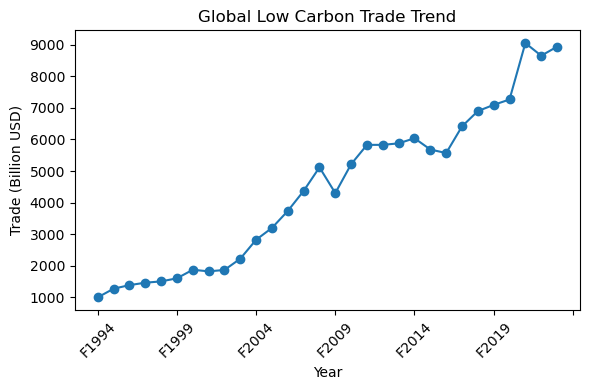

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
trend.plot(marker='o')

plt.title("Global Low Carbon Trade Trend")
plt.xlabel("Year")
plt.ylabel("Trade (Billion USD)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()